# Multivariate t (Student) Distribution

`MultivariateT(mean, cov, df)` generalizes Student's t-distribution to several dimensions -- the heavy-tailed counterpart of the `MultivariateNormal`. Each draw is a vector of correlated values; `cov` is the scale (shape) matrix and `df` sets the tail weight. As `df` grows it approaches a `MultivariateNormal(mean, cov)`.

In [1]:
from symbulate import *

## Draw a value

Each draw is a vector, one entry per dimension.

In [2]:
MultivariateT(mean=[0, 0], cov=[[1, 0], [0, 1]], df=5).draw()

(-0.628761526703407, -1.6180330460621166)

## Simulate

Confirm the draws are 2-dimensional vectors.

In [3]:
MultivariateT(mean=[0, 0], cov=[[1, 0], [0, 1]], df=5).sim(1000)

0,"(-1.3357912125716054, -0.8073889884701381)"
1,"(-0.29501044373411556, 0.8091742531939125)"
2,"(-0.33414312107534755, 0.7746155329550339)"
3,"(-0.037124506881510075, -0.8447007592622859)"
4,"(0.42107091506916217, -1.7032697218604687)"
5,"(1.26315567790123, 0.21819708642016122)"
6,"(-0.1653973148381364, -0.36305356374395364)"
7,"(-0.24580399166519484, -0.28273961996840813)"
8,"(2.147633374074105, -6.138042959215213)"
...,...
999,"(1.7062987192618244, 0.7682409001353424)"


## Evaluate the pdf at a point

In [4]:
MultivariateT(mean=[0, 0], cov=[[1, 0], [0, 1]], df=5).pdf([0, 0])

np.float64(0.15915494309189535)

## Relationship: each marginal is a Student's t

Each component of a multivariate t is a univariate Student's t with the same `df`, centered at that component's mean and scaled by the square root of its diagonal entry. Here the first component of `MultivariateT([3, 7], [[4, 0], [0, 9]], df=5)` is `3 + 2 * StudentT(5)` (location 3, scale sqrt(4) = 2).

Currently Showing: Density Plot
Alternative Plots: Histogram (Default), Rug Plot (type = "rug"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


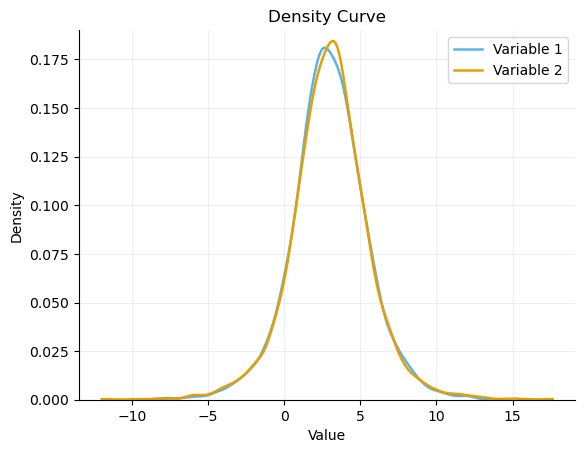

In [5]:
X, Y = RV(MultivariateT(mean=[3, 7], cov=[[4, 0], [0, 9]], df=5))
X.sim(10000).plot(type="density")
(3 + 2 * RV(StudentT(df=5))).sim(10000).plot(type="density")

## Relationship: large df approaches the multivariate normal

With `df = 1000` the marginal is indistinguishable from the corresponding normal.

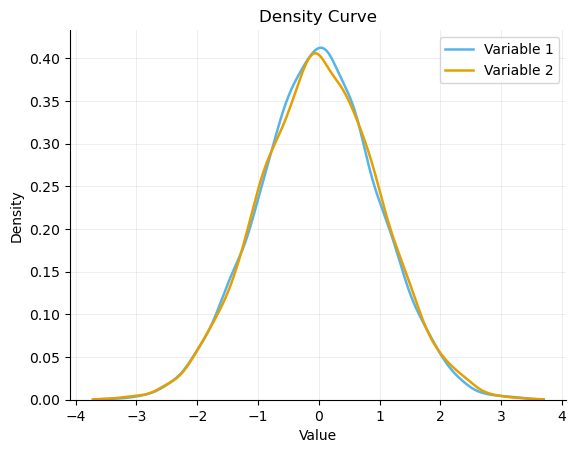

In [6]:
Xbig, _ = RV(MultivariateT(mean=[0, 0], cov=[[1, 0], [0, 1]], df=1000))
Xnorm, _ = RV(MultivariateNormal(mean=[0, 0], cov=[[1, 0], [0, 1]]))
Xbig.sim(10000).plot(type="density")
Xnorm.sim(10000).plot(type="density")